<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:15px; color:yellow; margin:0; font-size:150%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b>Farm Yield Analysis & Prediction | ML Models </b></div>

![Farm](https://farm.ws/wp-content/uploads/2024/11/What-is-Crop-Farming_-Everything-You-Need-to-Know.webp)

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:15px; color:yellow; margin:0; font-size:150%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b>Introduction  </b></div>

Agricultural productivity plays a vital role in food security and economic stability. Understanding the factors that influence crop yield is essential for optimizing farm practices and improving decision-making in modern agriculture.

This notebook focuses on **Farm Yield Analysis and Prediction** using machine learning techniques. The dataset includes detailed information about farm characteristics such as crop type, soil type, irrigation method, seasonal patterns, farm area, and resource usage including fertilizer, pesticide, and water consumption.

The primary objective of this analysis is to explore relationships between these variables, identify key factors that impact crop yield, and build predictive machine learning models to estimate crop yield based on input features. Through **Exploratory Data Analysis (EDA)** and modeling, this project aims to provide data-driven insights that can support efficient and sustainable farming practices.


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:yellow; margin:0; font-size:110%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b> About the Columns </b></div>

The dataset contains information related to farm characteristics, agricultural practices, and crop yield. Each column represents a factor that may influence the final crop production.

- **Farm_ID**  
  A unique identifier assigned to each farm.

- **Crop_Type**  
  The type of crop cultivated on the farm, such as Cotton, Carrot, or Wheat.

- **Irrigation_Type**  
  The method used to irrigate the crops, including Drip, Manual, or Flood irrigation.

- **Soil_Type**  
  The type of soil present on the farm, such as Loamy, Sandy, or Silty, which affects water retention and nutrient availability.

- **Season**  
  The growing season in which the crop is cultivated, such as Kharif, Rabi, or Zaid.

- **Farm_Area (acres)**  
  The total area of the farm measured in acres.

- **Fertilizer_Used (tons)**  
  The quantity of fertilizer applied to the crops.

- **Pesticide_Used (kg)**  
  The amount of pesticide used to protect crops from pests.

- **Water_Usage (cubic meters)**  
  The total amount of water used during the crop growing period.

- **Yield (tons)**  
  The total crop yield produced by the farm. This is the **target variable** used for prediction.


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:yellow; margin:0; font-size:110%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b> Modeling Approach </b></div>

To predict crop yield, several regression models were implemented and compared. These models were selected to capture both linear relationships and complex non-linear patterns within the data.

### Regression Models Used
-  **Linear Regression** – Serves as a baseline model to understand linear relationships.  
-  **Random Forest Regressor** – An ensemble model capable of handling non-linear interactions and feature importance.  
-  **XGBoost Regressor** – A gradient boosting model known for high performance and robustness.  
-  **CatBoost Regressor** – Particularly effective for datasets with categorical features and minimal preprocessing.

### 🏆 Best Performing Model
The **CatBoost Regressor** achieved the best performance based on evaluation metrics such as **Mean Squared Error (MSE)** and **R-squared (R²)**. Its strong handling of categorical variables and ability to model complex relationships made it the most effective model for this dataset.


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:15px; color:yellow; margin:0; font-size:150%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b>1.Installing Required Libraries & Load the Dataset </b></div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import plotly.graph_objects as go
from plotly.subplots import make_subplots


from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("/kaggle/input/agriculture-and-farming-dataset/agriculture_dataset.csv")

print("Dataset Loaded Sucessfully!")

Dataset Loaded Sucessfully!


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:15px; color:yellow; margin:0; font-size:150%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b>2. Data Exploration  </b></div>

In [2]:
# Display first 5 rows
print("\n First 5 rows of the dataset:")
display(df.head())

# Dataset info
print("\n Dataset Information:")
print(f"Number of records:{df.shape[0]:,}")
print(f"Number of features:{df.shape[1]:,}")

# Data types & missing values
print("\n Data types & Missing values:")
info_df = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing values": df.isnull().sum(),
    "Duplicated values": df.duplicated().sum(),
    "Unique Values": df.nunique()
})
display(info_df)

print("\nStatistical Summary:")
display(df.describe().T)


 First 5 rows of the dataset:


,Farm_ID,Crop_Type,Farm_Area(acres),Irrigation_Type,Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Soil_Type,Season,Water_Usage(cubic meters)
0,F001,Cotton,329.40,Sprinkler,8.14,2.21,14.44,Loamy,Kharif,76648.20
1,F002,Carrot,18.67,Manual,4.77,4.36,42.91,Peaty,Kharif,68725.54
2,F003,Sugarcane,306.03,Flood,2.91,0.56,33.44,Silty,Kharif,75538.56
3,F004,Tomato,380.21,Rain-fed,3.32,4.35,34.08,Silty,Zaid,45401.23
4,F005,Tomato,135.56,Sprinkler,8.33,4.48,43.28,Clay,Zaid,93718.69



 Dataset Information:
Number of records:50
Number of features:10

 Data types & Missing values:


,Data Type,Missing values,Duplicated values,Unique Values
Farm_ID,object,0,0,50
Crop_Type,object,0,0,10
Farm_Area(acres),float64,0,0,50
Irrigation_Type,object,0,0,5
Fertilizer_Used(tons),float64,0,0,49
Pesticide_Used(kg),float64,0,0,46
Yield(tons),float64,0,0,50
Soil_Type,object,0,0,5
Season,object,0,0,3
Water_Usage(cubic meters),float64,0,0,50



Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Farm_Area(acres),50.0,254.9638,139.417782,12.50,135.7100,281.980,368.1075,483.88
Fertilizer_Used(tons),50.0,4.9054,2.732689,0.50,2.4375,5.045,6.8850,9.96
Pesticide_Used(kg),50.0,2.3980,1.438613,0.14,0.9725,2.330,3.4175,4.99
Yield(tons),50.0,27.0592,13.345789,3.86,16.1900,28.970,37.8600,48.02
Water_Usage(cubic meters),50.0,56724.2956,27264.992053,5869.75,37818.1525,54097.075,82240.0325,94754.73


In [3]:
# Classification of Categorical & Numerical variables
def classify_variables(data):
    "Classify variables as categorical or numerical."
    categorical = []
    numerical = []

    for col in data.columns:
        if data[col].dtype == 'object':
            categorical.append(col)
        elif data[col].dtype in ['int64','float64']:
            if data[col].nunique() < 10:
                categorical.append(col)
            else:
                numerical.append(col)

    return categorical, numerical
cat_vars, num_vars = classify_variables(df)
print("Variables Classification:")
print('='*40)
print(f"Categorical Variables ({len(cat_vars)}:",cat_vars)
print(f"\nNumerical Variables ({len(num_vars)}:",num_vars)   

Variables Classification:
Categorical Variables (5: ['Farm_ID', 'Crop_Type', 'Irrigation_Type', 'Soil_Type', 'Season']

Numerical Variables (5: ['Farm_Area(acres)', 'Fertilizer_Used(tons)', 'Pesticide_Used(kg)', 'Yield(tons)', 'Water_Usage(cubic meters)']


**Observations:**

 * Dataset has 50 rows & 10 columns.
 * All values are non-null.
 * All values are non-duplicated
   
**Statistical Summary:** 
* The average farm area is about 255 acres, showing noticeable variation across farms.
* Fertilizer and pesticide usage vary, with average values of 4.9 tons and 2.4 kg, respectively.
* The average crop yield is approximately 27 tons.
* Water usage is relatively high, averaging around 56,724 cubic meters.

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:15px; color:yellow; margin:0; font-size:150%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b>3.  Exploratory Data Analysis  </b></div>

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:yellow; margin:0; font-size:110%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b> 3.1. Data Distribution of Numerical Features </b></div>

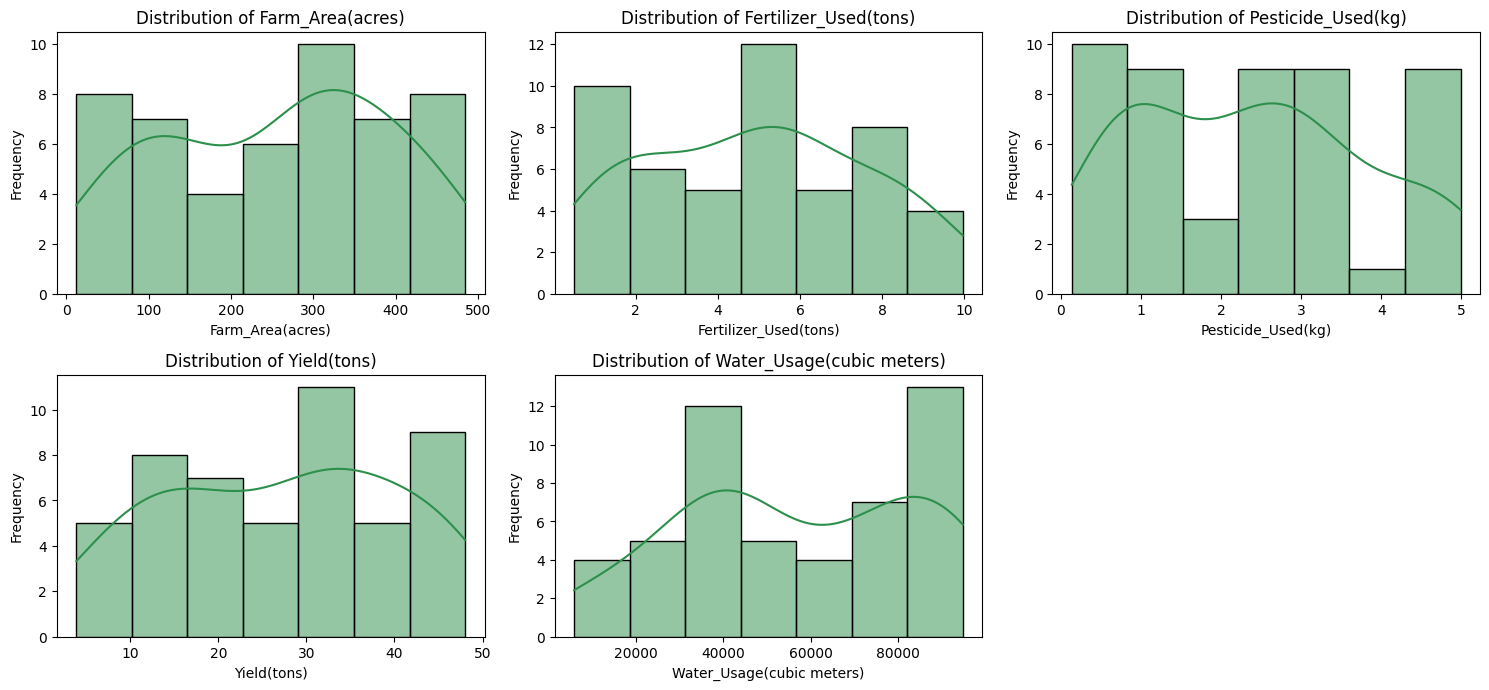

In [4]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot distribution for each numerical feature
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(
        df[col],
        kde=True,
        color=sns.color_palette('YlGn', as_cmap=False)[4]
    )
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()



**Insight**
* **Farm Area (acres):** The distribution is wide and slightly right-skewed, indicating that most farms are medium-sized, with a few very large farms.

* **Fertilizer Used (tons):** Fertilizer usage clusters around mid-range values, suggesting a common usage pattern, with a few high-usage outliers.

* **Pesticide Used (kg):** The distribution is left-skewed, meaning most farms use lower quantities, while only a few use much higher amounts.

* **Yield (tons):** Yield shows slight right skewness, with most farms producing moderate yields and a small number achieving higher yields.

* **Water Usage (cubic meters):** Water usage varies widely and is right-skewed, likely influenced by farm size, crop type, and irrigation practices.

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:yellow; margin:0; font-size:110%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b> 3.2.Univariate Analysis for numerical columns </b></div>


 Analysis of: Farm_Area(acres)
----------------------------------------
 Summary Statistics:


count     50.000000
mean     254.963800
std      139.417782
min       12.500000
25%      135.710000
50%      281.980000
75%      368.107500
max      483.880000
Name: Farm_Area(acres), dtype: float64

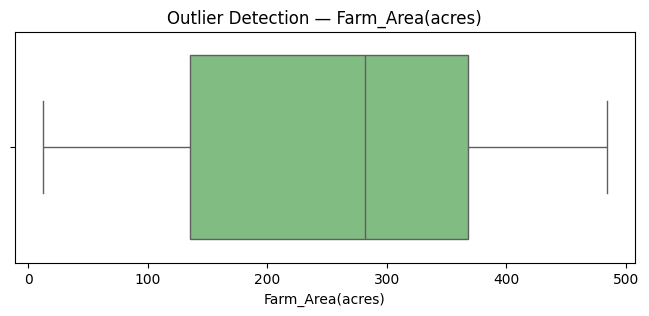


 Analysis of: Fertilizer_Used(tons)
----------------------------------------
 Summary Statistics:


count    50.000000
mean      4.905400
std       2.732689
min       0.500000
25%       2.437500
50%       5.045000
75%       6.885000
max       9.960000
Name: Fertilizer_Used(tons), dtype: float64

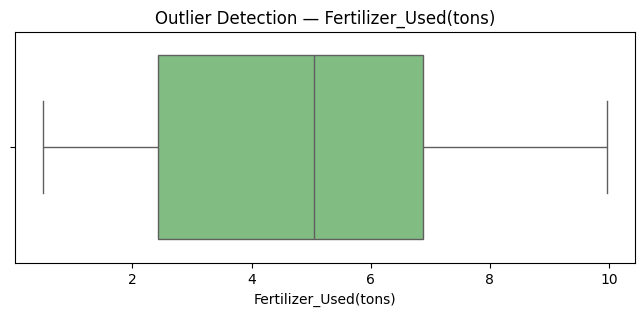


 Analysis of: Pesticide_Used(kg)
----------------------------------------
 Summary Statistics:


count    50.000000
mean      2.398000
std       1.438613
min       0.140000
25%       0.972500
50%       2.330000
75%       3.417500
max       4.990000
Name: Pesticide_Used(kg), dtype: float64

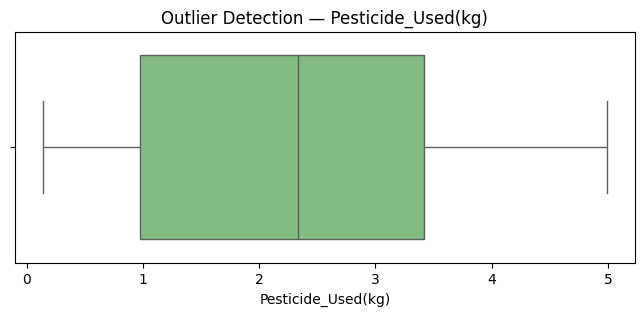


 Analysis of: Yield(tons)
----------------------------------------
 Summary Statistics:


count    50.000000
mean     27.059200
std      13.345789
min       3.860000
25%      16.190000
50%      28.970000
75%      37.860000
max      48.020000
Name: Yield(tons), dtype: float64

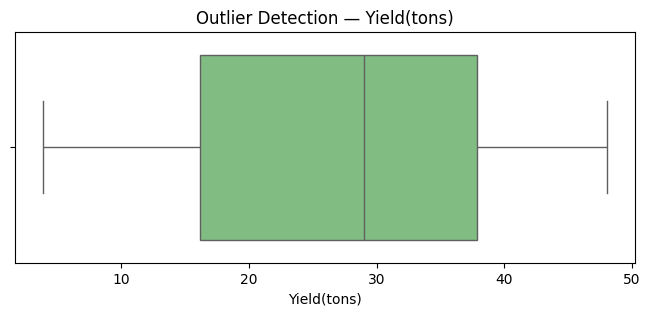


 Analysis of: Water_Usage(cubic meters)
----------------------------------------
 Summary Statistics:


count       50.000000
mean     56724.295600
std      27264.992053
min       5869.750000
25%      37818.152500
50%      54097.075000
75%      82240.032500
max      94754.730000
Name: Water_Usage(cubic meters), dtype: float64

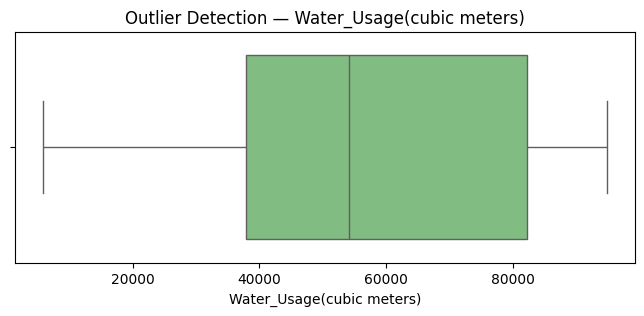

In [5]:
def univariate_numeric_analysis(df):
    """
    Univariate analysis for numerical columns:
    - Summary statistics
    - Boxplot for outlier detection
    """
    
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    
    for col in numeric_cols:
        print(f"\n Analysis of: {col}")
        print("-" * 40)
        
        # Summary statistics
        print(" Summary Statistics:")
        display(df[col].describe())
        
        # Boxplot only
        plt.figure(figsize=(8, 3))
        sns.boxplot(
            x=df[col],
            palette='YlGn'
        )
        plt.title(f'Outlier Detection — {col}')
        plt.show()

univariate_numeric_analysis(df)
      

**Insight**
* **Farm Area (acres):** Farm sizes vary widely (12.5–483.88 acres). The median is around 282 acres with a large IQR, indicating high variability. Larger farms appear as potential outliers.

* **Fertilizer Used (tons):** Usage ranges from 0.5 to 9.96 tons, with an average of about 4.9 tons. Most farms fall within the mid-range, while higher values suggest possible outliers.

* **Pesticide Used (kg):** Pesticide usage ranges from 0.14 to 4.99 kg, with a median near 2.33 kg. A few farms use significantly higher amounts, indicating outliers.

* **Yield (tons)**: Crop yield varies from 3.86 to 48.02 tons, with an average of 27.06 tons. The wide IQR shows yield differences likely influenced by farm size and input usage.

* **Water Usage (cubic meters):** Water consumption spans a broad range (5,869.75–94,754.73 m³). The high median and large IQR suggest substantial variation, with some farms using exceptionally high water volumes.

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:yellow; margin:0; font-size:110%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b> 3.3. Data Distribution of Categorical Features </b></div>


 Categorical Analysis: Crop_Type
--------------------------------------------------


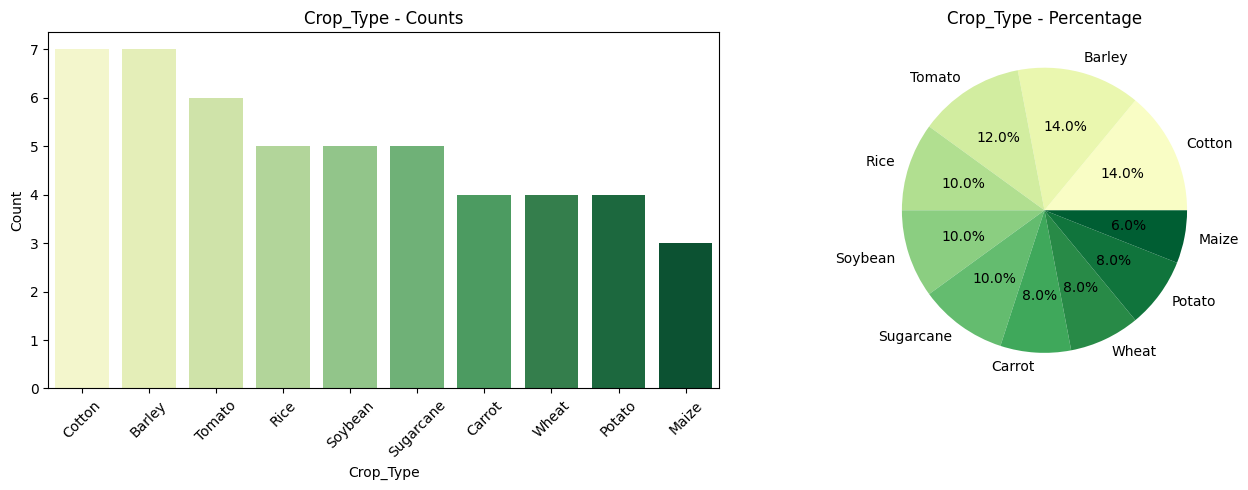


 Categorical Analysis: Irrigation_Type
--------------------------------------------------


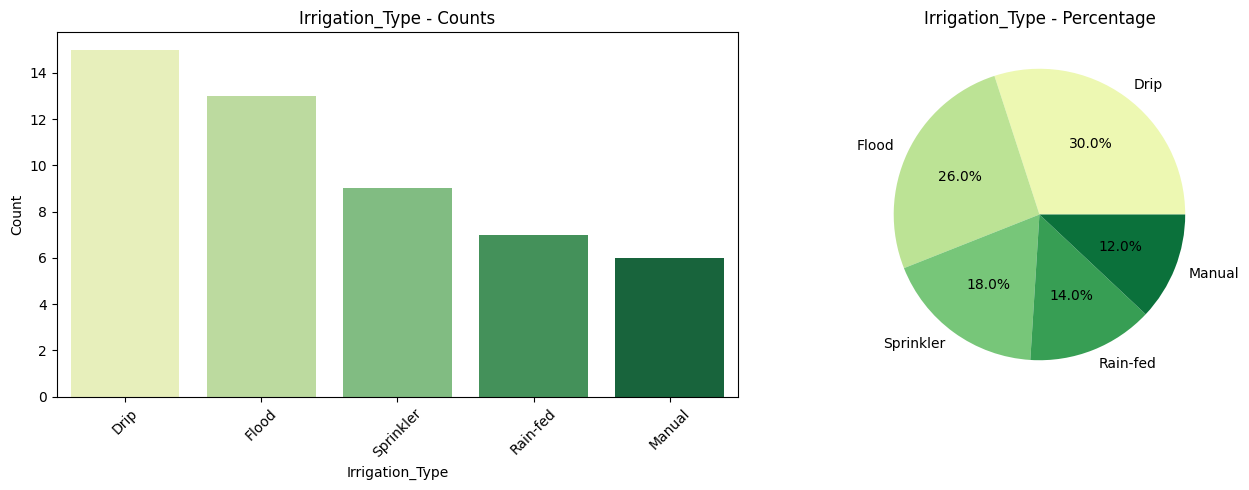


 Categorical Analysis: Soil_Type
--------------------------------------------------


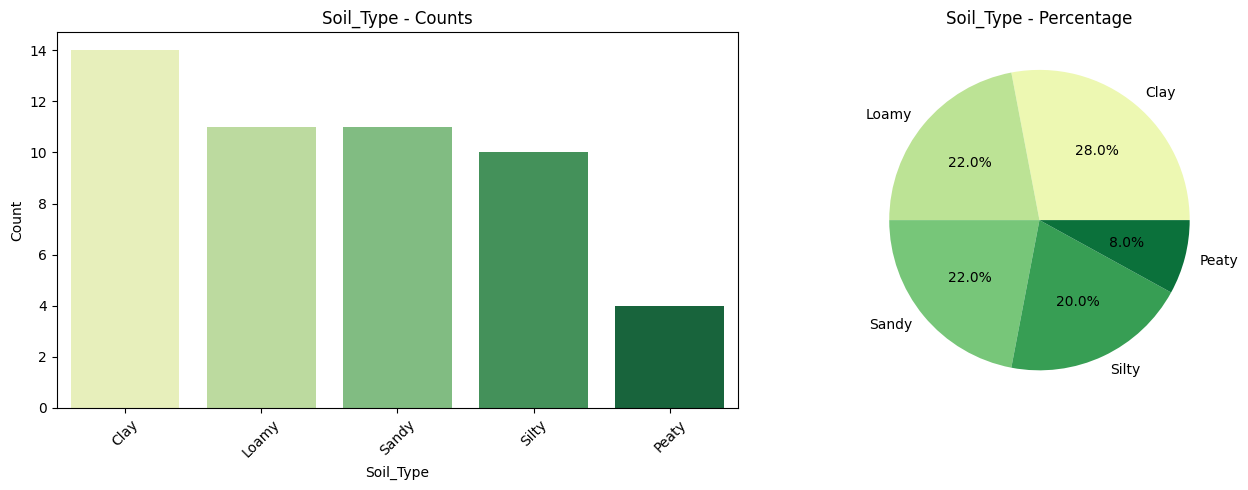


 Categorical Analysis: Season
--------------------------------------------------


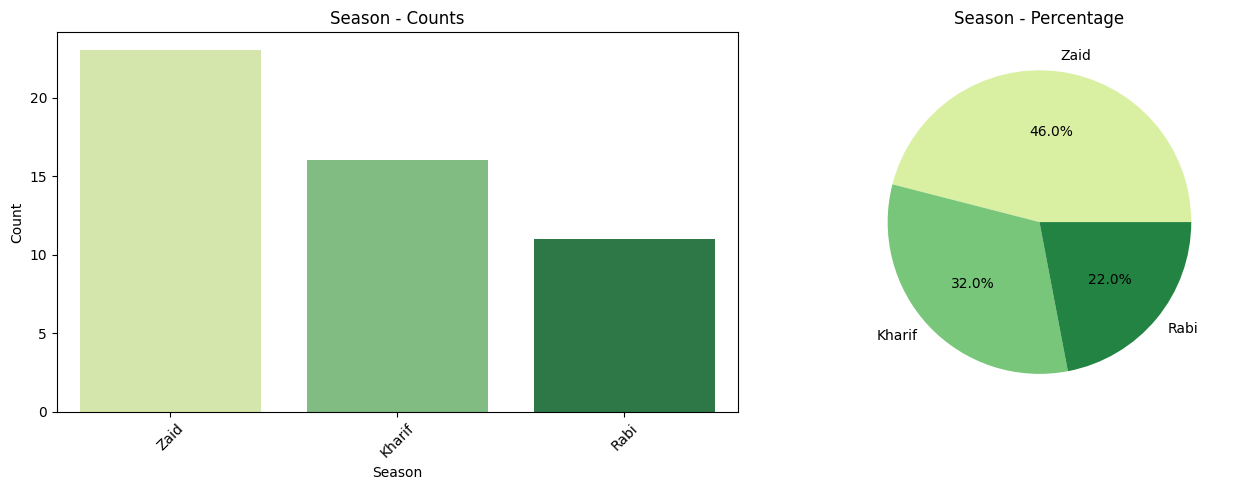

In [6]:
def categorical_bar_pie(df, max_categories=10, skip_columns=['Farm_ID']):
    """
    For each categorical column (except skip_columns):
    - Left: Bar chart of counts
    - Right: Pie chart of percentages
    """
    
    cat_cols = df.select_dtypes(include='object').columns
    cat_cols = [col for col in cat_cols if col not in skip_columns]
    
    for col in cat_cols:
        print(f"\n Categorical Analysis: {col}")
        print("-" * 50)
        
        # Top categories to avoid clutter
        value_counts = df[col].value_counts().head(max_categories)
        percentages = df[col].value_counts(normalize=True).head(max_categories) * 100
        
        # Create subplot
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Bar chart (counts)
        sns.barplot(
            x=value_counts.index,
            y=value_counts.values,
            palette='YlGn',
            ax=axes[0]
        )
        axes[0].set_title(f'{col} - Counts')
        axes[0].set_ylabel('Count')
        axes[0].set_xlabel(col)
        axes[0].tick_params(axis='x', rotation=45)
        
        # Pie chart (percentage)
        axes[1].pie(
            percentages,
            labels=percentages.index,
            autopct='%1.1f%%',
            colors=sns.color_palette('YlGn', n_colors=len(percentages))
        )
        axes[1].set_title(f'{col} - Percentage')
        
        plt.tight_layout()
        plt.show()
categorical_bar_pie(df)

**Insight**
* **Crop Type:** The dataset contains a diverse range of crops. Cotton, Carrot, and Tomato are the most frequently cultivated, while Potato and Barley appear less often. This diversity may lead to differences in input requirements and yield outcomes.

* **Irrigation Type:** Irrigation practices vary across farms. Manual and Sprinkler methods are the most common, whereas Drip and Rain-fed irrigation are less frequently used. This pattern may influence water efficiency and overall crop productivity.

* **Soil Type:** Soil types are fairly balanced, with Loamy and Silty soils being the most prevalent, followed by Peaty, Clay, and Sandy soils. This variation reflects differing soil conditions that can affect crop growth and yield potential.

* **Season:** The Kharif season dominates the dataset, followed by Zaid and Rabi. This indicates that most farming activity occurs during the Kharif season, likely due to favorable climatic conditions and crop cycles.

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:yellow; margin:0; font-size:110%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b> 3.4. Identifying crop types with highest and lowest values for different metrics </b></div>

In [7]:
# List of numeric metrics to analyze
metrics = ['Yield(tons)', 'Fertilizer_Used(tons)', 'Pesticide_Used(kg)',
           'Water_Usage(cubic meters)', 'Farm_Area(acres)']

# Prepare summary
summary_list = []

for metric in metrics:
    # Top crop
    top_crop = df.loc[df[metric].idxmax()]
    summary_list.append({
        'Metric': f'Highest {metric}',
        'Crop_Type': top_crop['Crop_Type'],
        'Value': top_crop[metric]
    })
    
    # Bottom crop
    bottom_crop = df.loc[df[metric].idxmin()]
    summary_list.append({
        'Metric': f'Lowest {metric}',
        'Crop_Type': bottom_crop['Crop_Type'],
        'Value': bottom_crop[metric]
    })

# Convert to DataFrame
metrics_summary_df = pd.DataFrame(summary_list)

# Display 
metrics_summary_df


,Metric,Crop_Type,Value
0,Highest Yield(tons),Tomato,48.02
1,Lowest Yield(tons),Maize,3.86
2,Highest Fertilizer_Used(tons),Cotton,9.96
3,Lowest Fertilizer_Used(tons),Cotton,0.50
4,Highest Pesticide_Used(kg),Rice,4.99
5,Lowest Pesticide_Used(kg),Barley,0.14
6,Highest Water_Usage(cubic meters),Cotton,94754.73
7,Lowest Water_Usage(cubic meters),Rice,5869.75
8,Highest Farm_Area(acres),Rice,483.88
9,Lowest Farm_Area(acres),Sugarcane,12.50


**Insight**
* **Yield:** Tomato records the highest yield (48.02 tons), highlighting its strong productivity under favorable conditions, while Maize shows the lowest yield (3.86 tons), possibly due to lower efficiency or cultivation challenges.

* **Fertilizer Usage:** Cotton exhibits the highest fertilizer usage (9.96 tons), indicating high nutrient requirements. Interestingly, Cotton also shows the lowest usage (0.50 tons) in some cases, reflecting variability in farming practices.

* **Pesticide Usage:** Rice has the highest pesticide usage (4.99 kg), suggesting greater pest pressure, whereas Barley uses the least (0.14 kg), indicating lower pest susceptibility or minimal chemical intervention.

* **Water Usage:** Cotton is the most water-intensive crop, consuming up to 94,754.73 cubic meters. In contrast, Rice shows the lowest water usage (5,869.75 cubic meters), possibly due to water-efficient cultivation methods.

* **Farm Area:** Rice occupies the largest farm area (483.88 acres), reflecting its regional importance, while Sugarcane is cultivated on the smallest area (12.50 acres), suggesting limited or niche production.

In [8]:
# Checking if any farms have multiple crop types
multiple_crops_per_farm = df.groupby('Farm_ID')['Crop_Type'].nunique().reset_index()
multiple_crops_per_farm = multiple_crops_per_farm[multiple_crops_per_farm['Crop_Type'] > 1]

# Displaying the result or a message if no farm has multiple crops
if not multiple_crops_per_farm.empty:
    import ace_tools as tools; tools.display_dataframe_to_user(name="Farms with Multiple Crop Types", dataframe=multiple_crops_per_farm)
else:
    print("No farms have multiple crop types.")

No farms have multiple crop types.


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:yellow; margin:0; font-size:110%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b> 3.5. Farm & Farm Area Distribution by Crop type </b></div>

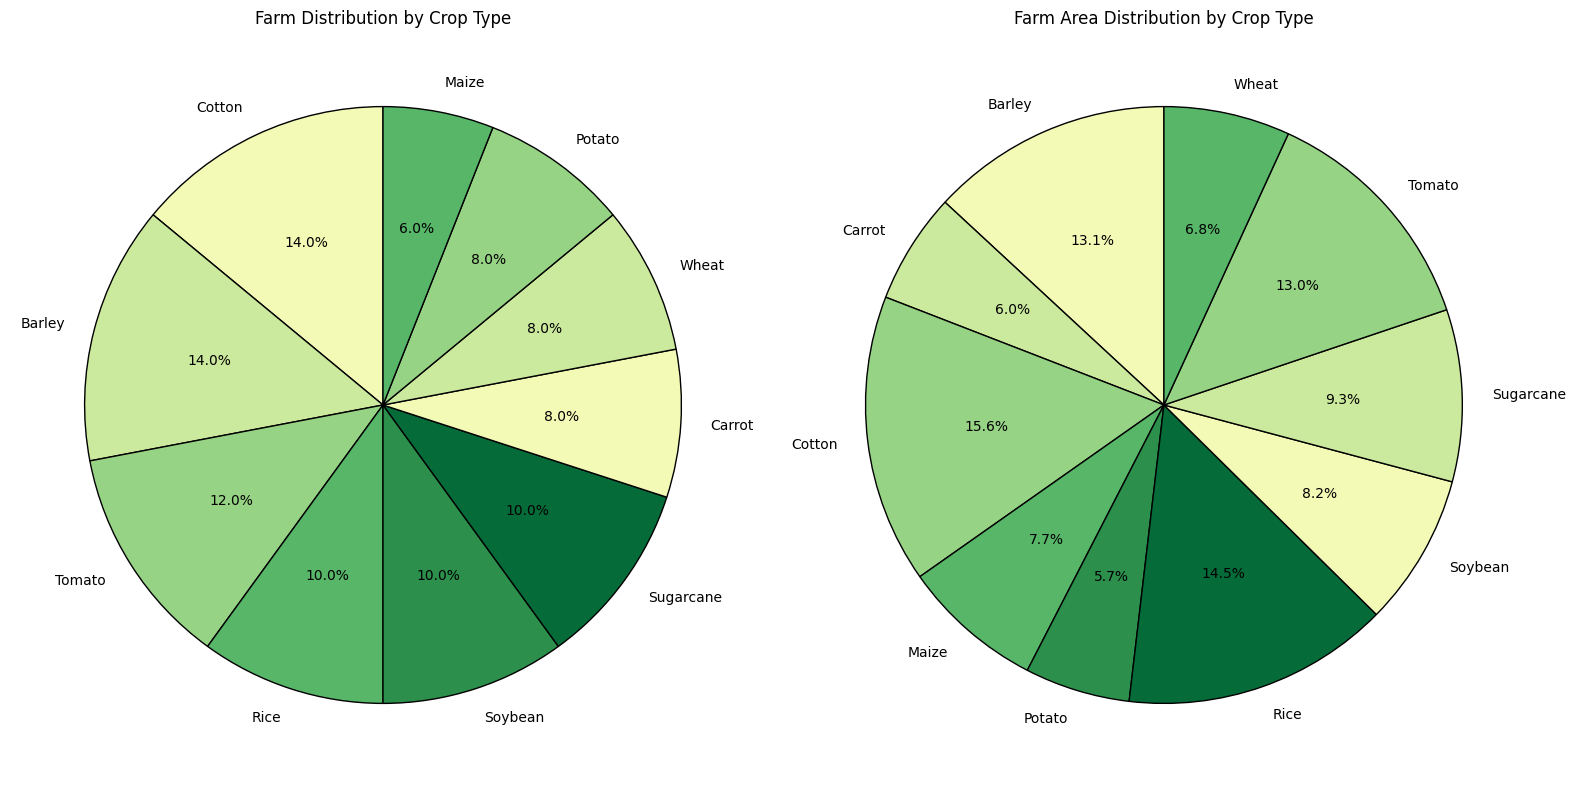

In [9]:
# Prepare data
crop_type_counts = df['Crop_Type'].value_counts()
total_area_per_crop = df.groupby('Crop_Type')['Farm_Area(acres)'].sum()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

#  Farm distribution by crop type
axes[0].pie(
    crop_type_counts,
    labels=crop_type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('YlGn'),
    wedgeprops={'edgecolor': 'black'}
)
axes[0].set_title('Farm Distribution by Crop Type')

#  Farm area distribution by crop type
axes[1].pie(
    total_area_per_crop,
    labels=total_area_per_crop.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('YlGn'),
    wedgeprops={'edgecolor': 'black'}
)
axes[1].set_title('Farm Area Distribution by Crop Type')

plt.tight_layout()
plt.show()


**Crop Type & Farm -Insight**
* Each farm grows only one crop, indicating strong crop specialization.

* Cotton, Barley, and Tomato are grown by more farms, while Maize and Potato are less common.

* The distribution highlights crop popularity and regional farming focus.

* Specialization may be influenced by soil, water availability, climate, or economic factors.

 **Farm Area Distribution- Insight** 
* **Largest Areas:** Cotton, Rice, and Barley cover the   most land, indicating high priority or economic importance.

*  **Moderate Areas:** Tomato, Sugarcane, and Soybean have considerable but comparatively lower land allocation.

* **Smaller Areas:** Carrot, Wheat, Maize, and Potato occupy the least area, suggesting lower demand or more land-efficient cultivation.

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:yellow; margin:0; font-size:110%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b> 3.6. Crop Types and Their Corresponding Soil Types </b></div>

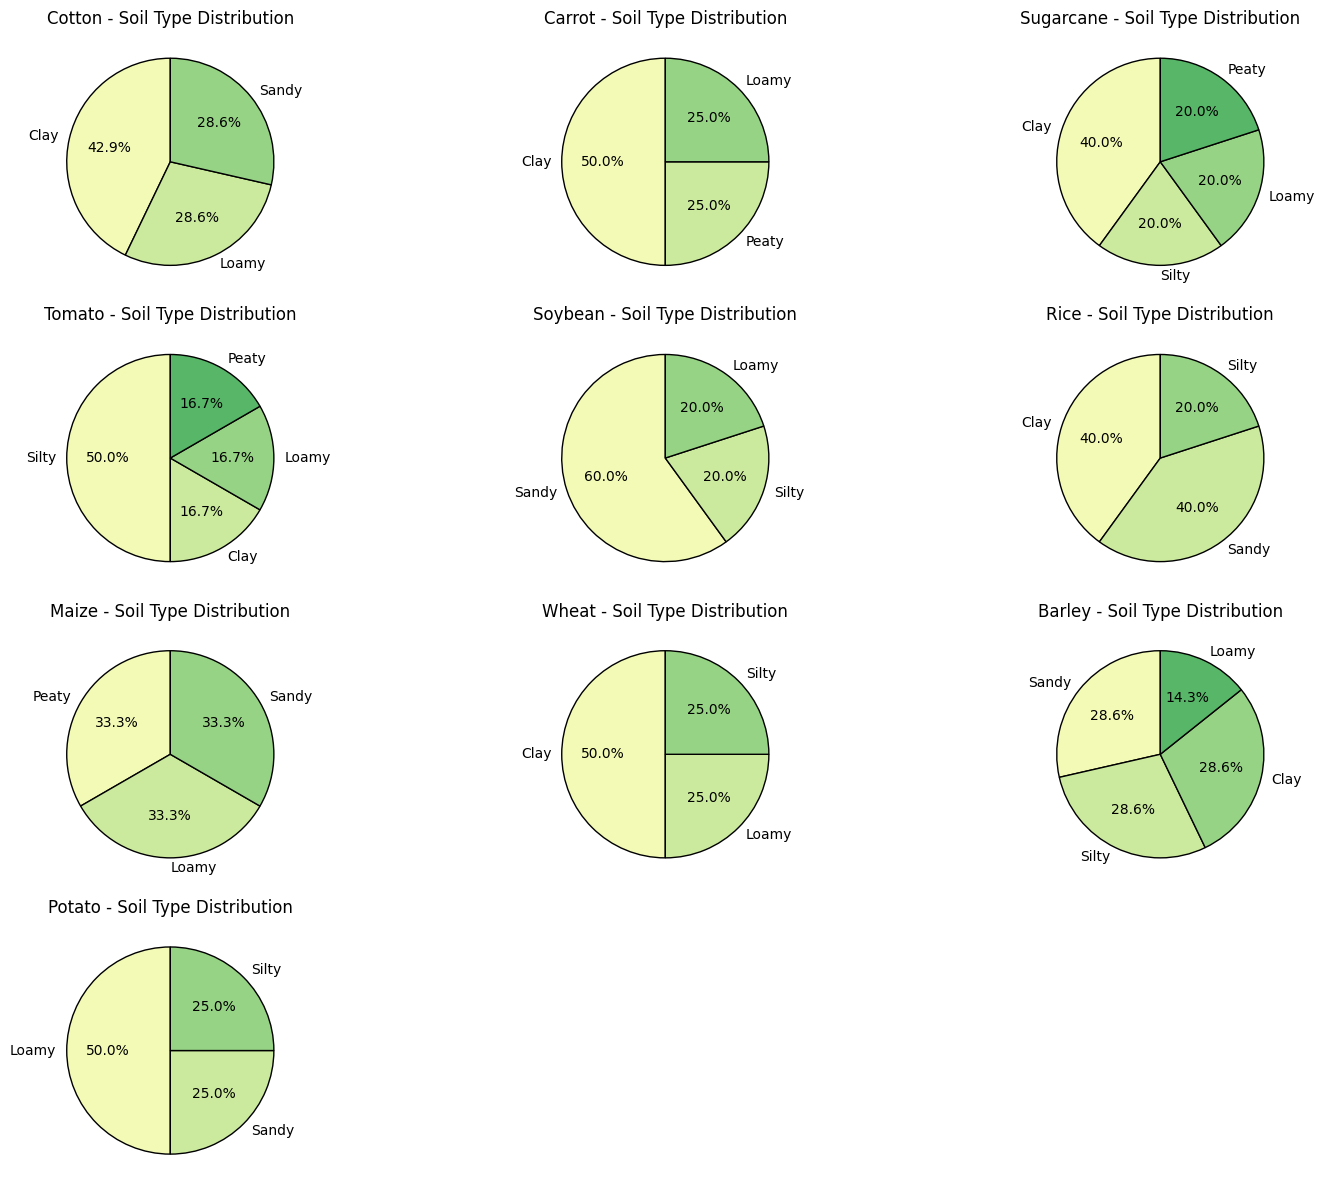

In [10]:
# Identifying the crop types and the corresponding soil types they grow in
crop_soil_table = df.groupby('Crop_Type')['Soil_Type'].unique().reset_index()

crop_soil_table
# Plotting pie charts for each crop type to show distribution of soil types they grow in
unique_crops = df['Crop_Type'].unique()

# Set up a grid for multiple pie charts
plt.figure(figsize=(15, 12))
for i, crop in enumerate(unique_crops, 1):
    plt.subplot(4, 3, i)
    soil_distribution = df[df['Crop_Type'] == crop]['Soil_Type'].value_counts()
    plt.pie(soil_distribution, labels=soil_distribution.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('YlGn'), wedgeprops={'edgecolor': 'black'})
    plt.title(f'{crop} - Soil Type Distribution')

plt.tight_layout()
plt.show()


**Soil Type -Insights**
* **Highly Adaptable Crops:** Barley, Tomato, and Sugarcane grow across multiple soil types, showing strong adaptability.

* **Specific Soil Preference:** Carrot and Soybean are linked to fewer soil types, indicating more selective soil requirements.

* **Common Soils:** Sandy and Loamy soils support many crops, making them the most prevalent and versatile soil types.

* **Limited Peaty Soil Use:** Peaty soil appears with only a few crops, suggesting limited availability or suitability. 

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:yellow; margin:0; font-size:110%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b> 3.7. Seasonal Distribution of Crops
 </b></div>

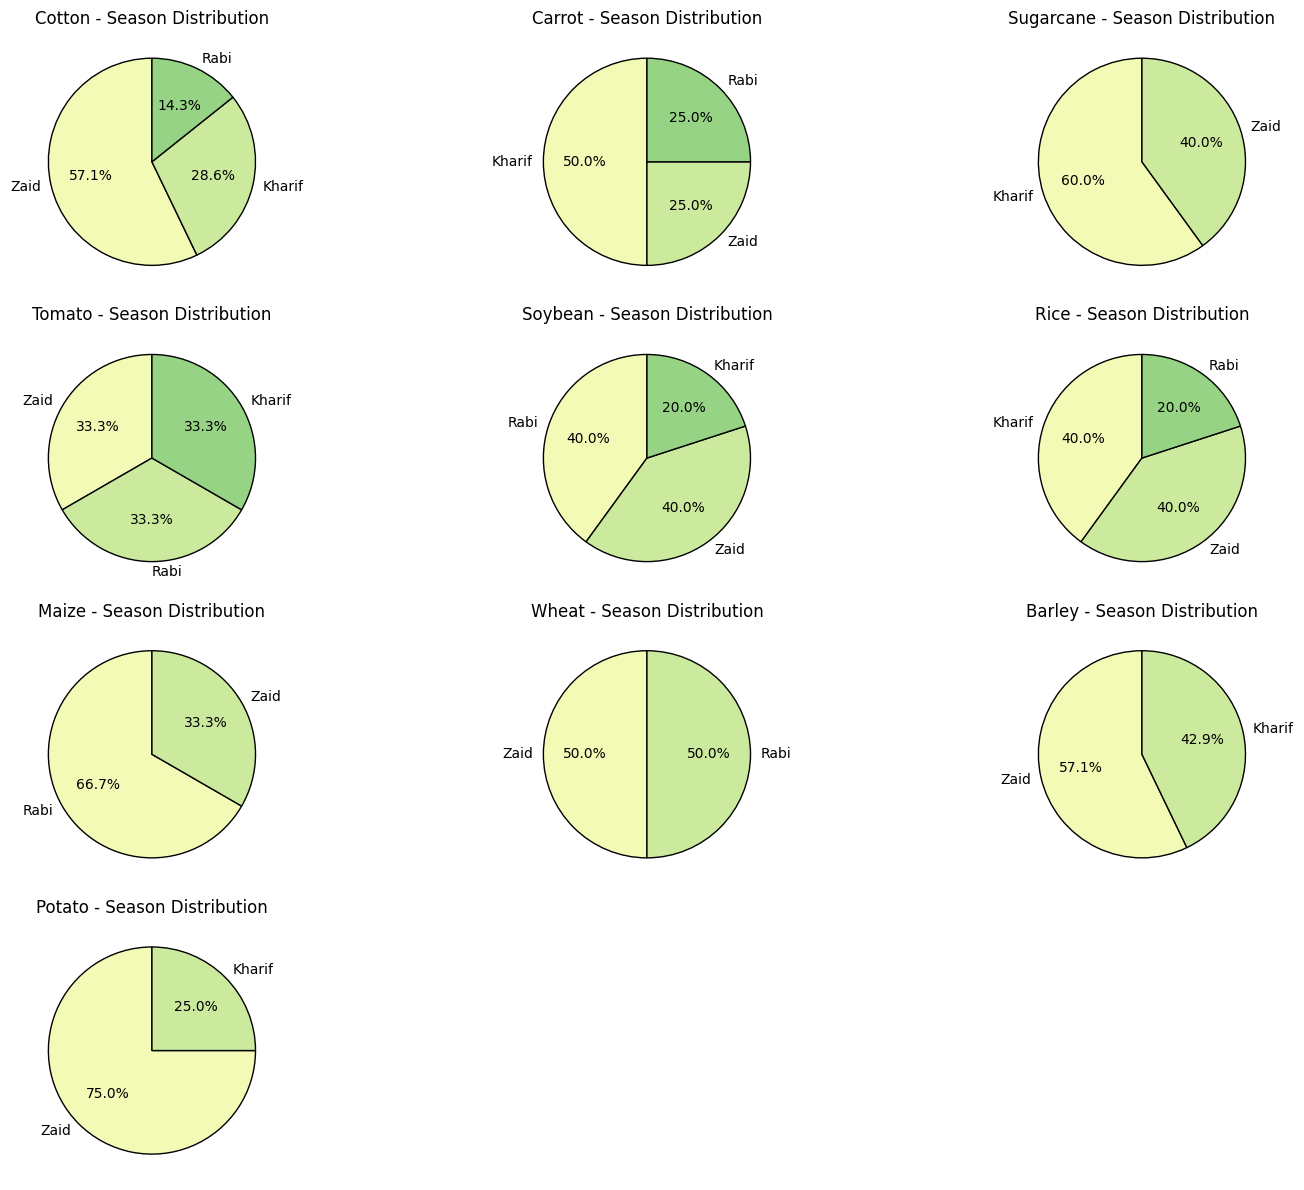

In [11]:
# Plotting pie charts for each crop type to show distribution of seasons they are grown in
plt.figure(figsize=(15, 12))
for i, crop in enumerate(df['Crop_Type'].unique(), 1):
    plt.subplot(4, 3, i)
    season_distribution = df[df['Crop_Type'] == crop]['Season'].value_counts()
    plt.pie(season_distribution, labels=season_distribution.index, autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('YlGn'), wedgeprops={'edgecolor': 'black'})
    plt.title(f'{crop} - Season Distribution')

plt.tight_layout()
plt.show()

**Season-wise Crop -Insights**
* **Multi-season Crops:** Carrot, Rice, Soybean, and Tomato are grown in all three seasons, showing high adaptability. Cotton also spans all seasons but is mainly grown in Kharif.

* **Season-specific Crops:** Maize and Wheat are limited to Rabi and Zaid, while Sugarcane is mainly grown in Kharif and Zaid.

* **Dominant Seasons:** Potato is mostly grown in Zaid, while Barley and Cotton are concentrated in Kharif and Zaid.

* **Balanced Crops:** Tomato is evenly distributed across seasons, and Wheat shows a balanced split between Zaid and Rabi.

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:yellow; margin:0; font-size:110%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b> 3.9. Highest vs Lowest Agricultural Metrics
 </b></div>

In [12]:
rows_high = []
rows_low = []

# Metrics configuration
configs = [
    ('Yield(tons)', ['Soil_Type']),
    ('Fertilizer_Used(tons)', ['Soil_Type']),
    ('Water_Usage(cubic meters)', ['Soil_Type']),
    ('Water_Usage(cubic meters)', ['Soil_Type', 'Irrigation_Type']),
    ('Pesticide_Used(kg)', ['Season'])
]
for metric, group_cols in configs:
    grouped = df.groupby(['Crop_Type'] + group_cols)[metric].mean().reset_index()
    
    for crop in grouped['Crop_Type'].unique():
        temp = grouped[grouped['Crop_Type'] == crop]
        
        high = temp.loc[temp[metric].idxmax()]
        low = temp.loc[temp[metric].idxmin()]
        
        rows_high.append({
            'Crop_Type': crop,
            'Metric': metric,
            'Context': ', '.join([str(high[col]) for col in group_cols]),
            'Value': round(high[metric], 2)
        })
        
        rows_low.append({
            'Crop_Type': crop,
            'Metric': metric,
            'Context': ', '.join([str(low[col]) for col in group_cols]),
            'Value': round(low[metric], 2)
        })
        
highest_df = pd.DataFrame(rows_high)
lowest_df = pd.DataFrame(rows_low)

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "table"}, {"type": "table"}]],
    subplot_titles=("🔺 Highest Values", "🔻 Lowest Values")
)

# Highest values table
fig.add_trace(
    go.Table(
        header=dict(
            values=list(highest_df.columns),
            fill_color='lightgreen',
            align='left'
        ),
        cells=dict(
            values=[highest_df[col] for col in highest_df.columns],
            fill_color='white',
            align='left'
        )
    ),
    row=1, col=1
)

# Lowest values table
fig.add_trace(
    go.Table(
        header=dict(
            values=list(lowest_df.columns),
            fill_color='lightcoral',
            align='left'
        ),
        cells=dict(
            values=[lowest_df[col] for col in lowest_df.columns],
            fill_color='white',
            align='left'
        )
    ),
    row=1, col=2
)

fig.update_layout(
    height=600,
    title_text="Comparative Analysis: Highest vs Lowest Agricultural Metrics",
    showlegend=False
)

fig.show()


**Insight**

* Yield varies significantly across soil types, indicating that soil quality plays a crucial role in crop productivity.
* Higher fertilizer usage does not always lead to higher yields, suggesting diminishing returns or inefficient application in certain crops.
* Water usage shows strong variation based on both soil and irrigation methods, highlighting the importance of optimized irrigation strategies.
* Some crop–soil–irrigation combinations consume excessive water while delivering lower output, indicating potential areas for resource optimization.
* Pesticide usage is season-dependent, with certain seasons requiring more pest control due to environmental conditions.

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:yellow; margin:0; font-size:110%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b> 3.10. Resource Usage & Yield by Irrigation Type
 </b></div>

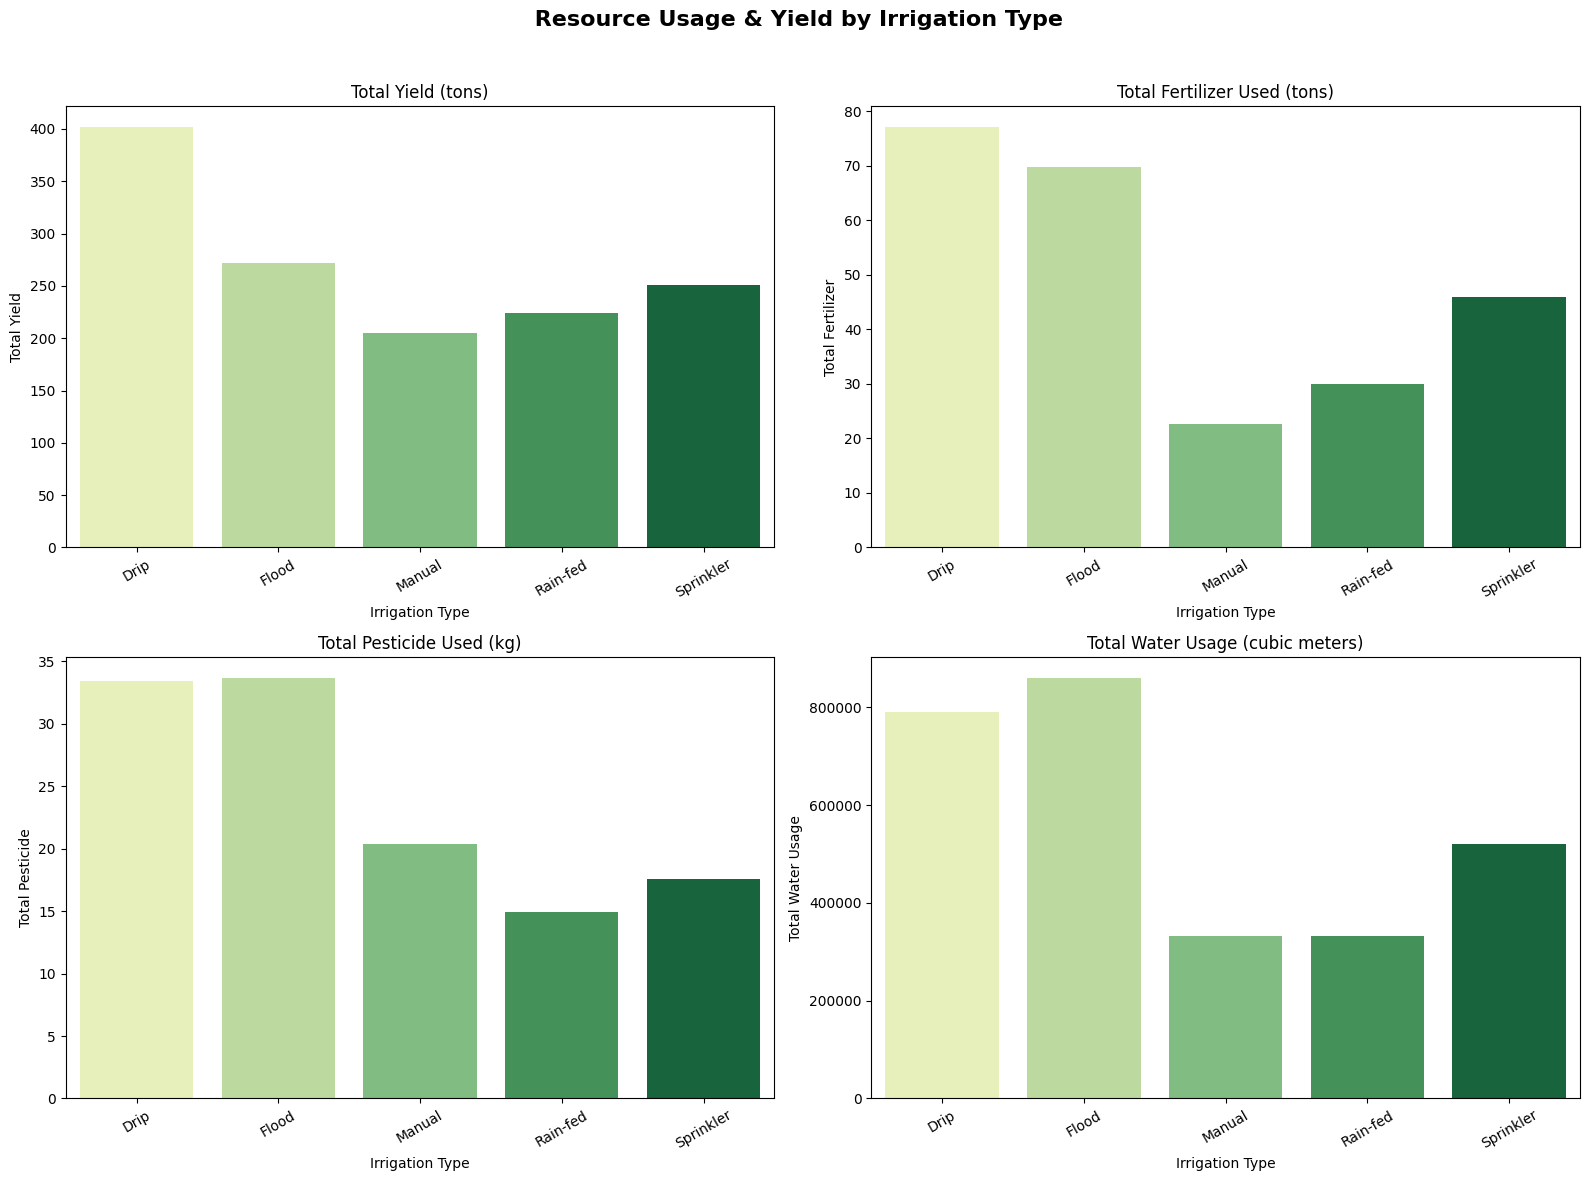

In [13]:
# Aggregate totals by Irrigation Type
irrigation_summary = df.groupby('Irrigation_Type').agg({
    'Yield(tons)': 'sum',
    'Fertilizer_Used(tons)': 'sum',
    'Pesticide_Used(kg)': 'sum',
    'Water_Usage(cubic meters)': 'sum'
}).reset_index()

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(' Resource Usage & Yield by Irrigation Type', fontsize=16, fontweight='bold')

#  Total Yield
sns.barplot(
    data=irrigation_summary,
    x='Irrigation_Type',
    y='Yield(tons)',
    palette='YlGn',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Total Yield (tons)')
axes[0, 0].set_ylabel('Total Yield')

# Total Fertilizer Used
sns.barplot(
    data=irrigation_summary,
    x='Irrigation_Type',
    y='Fertilizer_Used(tons)',
    palette='YlGn',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Total Fertilizer Used (tons)')
axes[0, 1].set_ylabel('Total Fertilizer')

# Total Pesticide Used
sns.barplot(
    data=irrigation_summary,
    x='Irrigation_Type',
    y='Pesticide_Used(kg)',
    palette='YlGn',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Total Pesticide Used (kg)')
axes[1, 0].set_ylabel('Total Pesticide')

#  Total Water Usage
sns.barplot(
    data=irrigation_summary,
    x='Irrigation_Type',
    y='Water_Usage(cubic meters)',
    palette='YlGn',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Total Water Usage (cubic meters)')
axes[1, 1].set_ylabel('Total Water Usage')

# Final layout
for ax in axes.flat:
    ax.set_xlabel('Irrigation Type')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


##  Irrigation Type Analysis – Summary

1. **Total Crop Yield by Irrigation Type**  
   - **Drip:** High yield due to controlled water delivery.  
   - **Flood:** High yield, suitable for water-demanding crops like rice, but may be inefficient.  
   - **Sprinkler & Manual:** Moderate yields.  
   - **Rain-fed:** Lowest yield due to limited water control.  

2. **Total Fertilizer Used by Irrigation Type**  
   - **Flood:** Highest usage, possibly due to nutrient leaching.  
   - **Drip & Sprinkler:** Moderate, efficient application near roots.  
   - **Manual & Rain-fed:** Lowest usage, reflecting reduced input.  

3. **Total Pesticide Usage by Irrigation Type**  
   - **Sprinkler & Drip:** High usage; controlled irrigation can favor pests.  
   - **Flood:** High usage due to humid, waterlogged conditions.  
   - **Manual & Rain-fed:** Lower usage, less intensive pest control.  

4. **Total Water Usage by Irrigation Type**  
   - **Flood:** Highest water use, inefficient method.  
   - **Drip & Sprinkler:** Moderate, more efficient.  
   - **Manual & Rain-fed:** Lowest water use; rain-fed depends on natural rainfall.  


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:yellow; margin:0; font-size:110%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b> 3.11. Seasonal Impact on Crop Yield & Resource Usage
 </b></div>

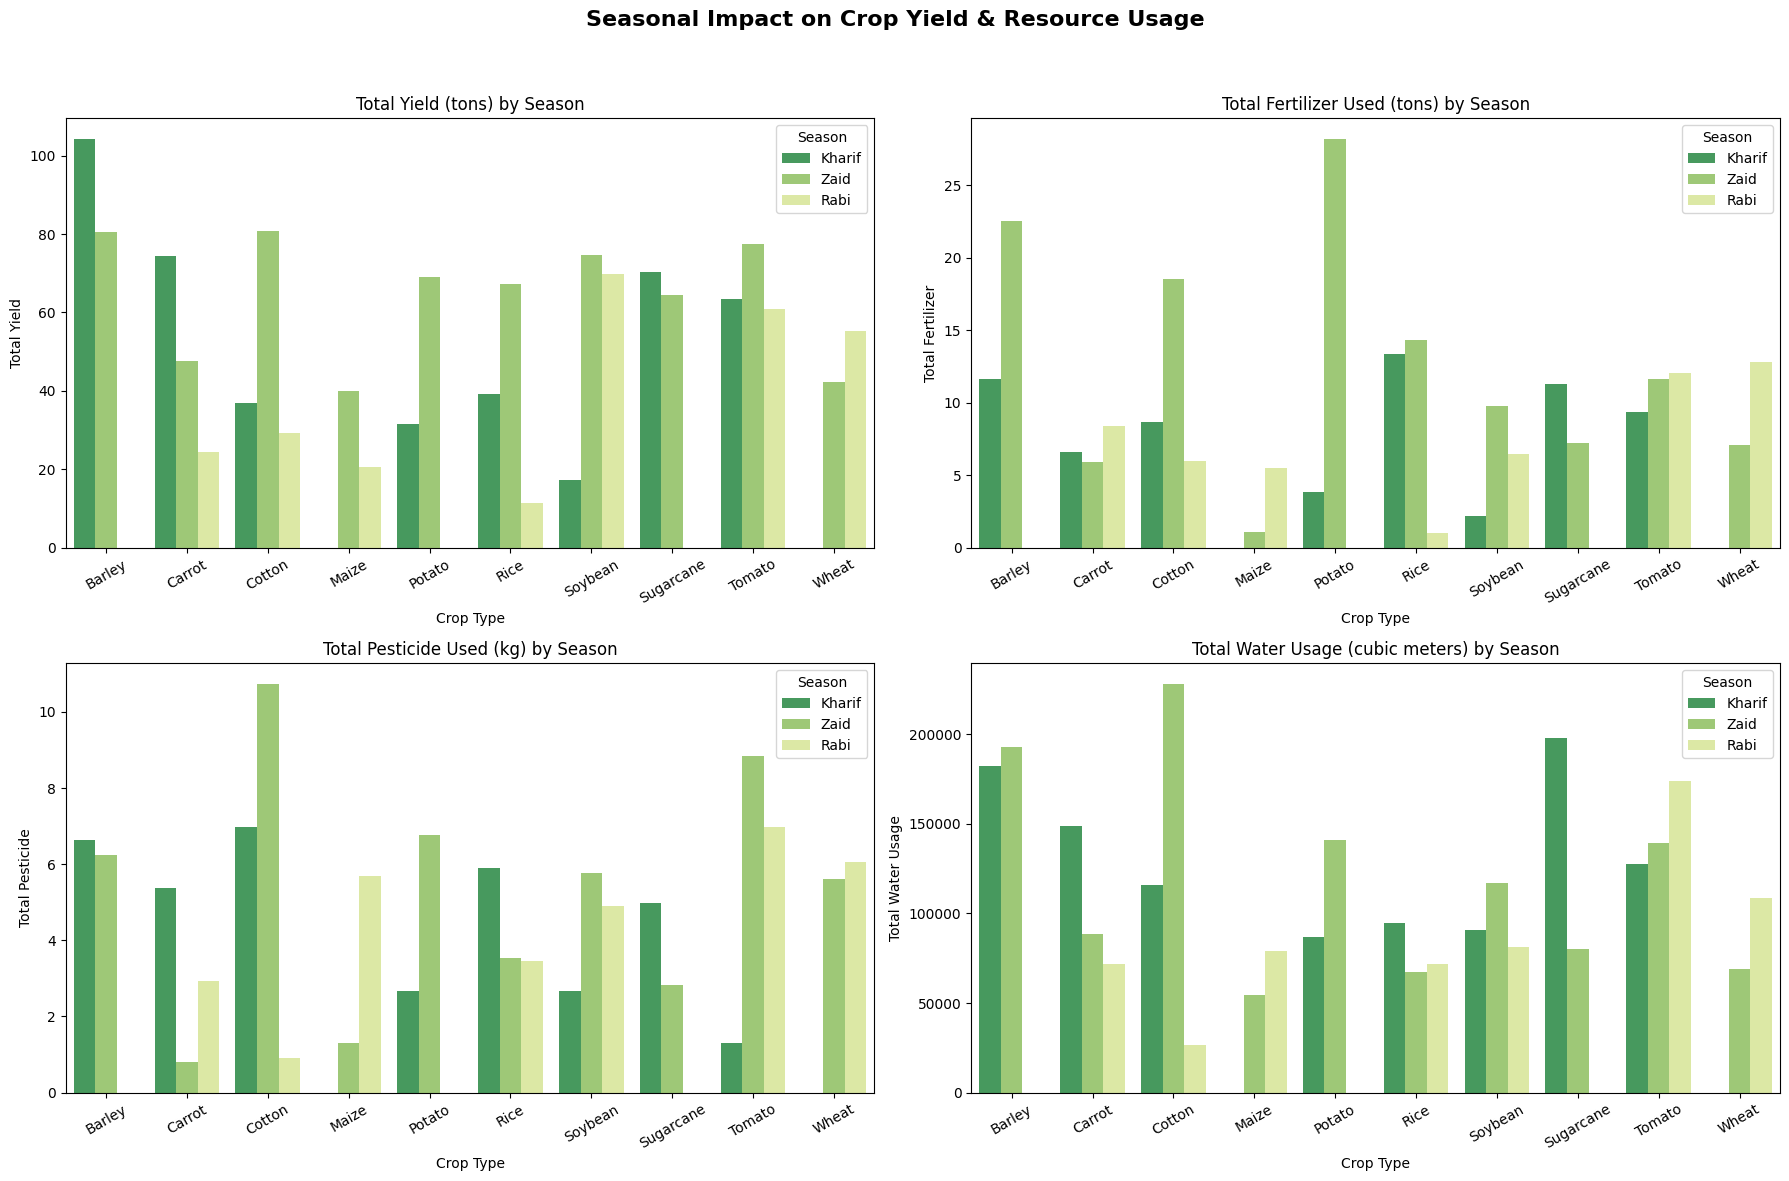

In [14]:
# Aggregate totals by Crop_Type & Season
season_crop_summary = df.groupby(
    ['Crop_Type', 'Season']
).agg({
    'Yield(tons)': 'sum',
    'Fertilizer_Used(tons)': 'sum',
    'Pesticide_Used(kg)': 'sum',
    'Water_Usage(cubic meters)': 'sum'
}).reset_index()

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(
    'Seasonal Impact on Crop Yield & Resource Usage',
    fontsize=16,
    fontweight='bold'
)

#  Crop Yield by Season
sns.barplot(
    data=season_crop_summary,
    x='Crop_Type',
    y='Yield(tons)',
    hue='Season',
    palette = sns.color_palette('RdYlGn')[::-1],
    ax=axes[0, 0]
)
axes[0, 0].set_title('Total Yield (tons) by Season')
axes[0, 0].set_ylabel('Total Yield')

# Fertilizer Used by Season
sns.barplot(
    data=season_crop_summary,
    x='Crop_Type',
    y='Fertilizer_Used(tons)',
    hue='Season',
    palette = sns.color_palette('RdYlGn')[::-1],
    ax=axes[0, 1]
)
axes[0, 1].set_title('Total Fertilizer Used (tons) by Season')
axes[0, 1].set_ylabel('Total Fertilizer')

# Pesticide Used by Season
sns.barplot(
    data=season_crop_summary,
    x='Crop_Type',
    y='Pesticide_Used(kg)',
    hue='Season',
    palette = sns.color_palette('RdYlGn')[::-1],
    ax=axes[1, 0]
)
axes[1, 0].set_title('Total Pesticide Used (kg) by Season')
axes[1, 0].set_ylabel('Total Pesticide')

#  Water Usage by Season
sns.barplot(
    data=season_crop_summary,
    x='Crop_Type',
    y='Water_Usage(cubic meters)',
    hue='Season',
    palette = sns.color_palette('RdYlGn')[::-1],
    ax=axes[1, 1]
)
axes[1, 1].set_title('Total Water Usage (cubic meters) by Season')
axes[1, 1].set_ylabel('Total Water Usage')

# Formatting
for ax in axes.flat:
    ax.set_xlabel('Crop Type')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Season')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


##  Crop & Season Analysis – Summary

1. **Yield (tons) by Crop and Season**  
   - **Kharif:** High yields for Rice, Cotton, Maize – favorable monsoon conditions.  
   - **Rabi:** Moderate yields for Wheat, Barley, Carrot – controlled irrigation, cooler climate.  
   - **Zaid:** Generally lower yields, though Tomato and some vegetables perform well.  

2. **Fertilizer Used (tons) by Crop and Season**  
   - **Kharif:** High usage for Rice, Cotton – intensive nutrient management.  
   - **Rabi:** Moderate usage for Wheat, Barley – stable, less intensive.  
   - **Zaid:** Lower usage – shorter season, less resource-intensive.  

3. **Pesticide Used (kg) by Crop and Season**  
   - **Kharif:** High usage for Rice, Cotton, Sugarcane – warm, humid conditions increase pest pressure.  
   - **Rabi:** Moderate usage – cooler, fewer pests.  
   - **Zaid:** Lowest usage – dry conditions reduce pest activity.  

4. **Water Usage (cubic meters) by Crop and Season**  
   - **Kharif:** Highest water usage, especially for Rice and Sugarcane – relies on monsoon and irrigation.  
   - **Rabi:** Moderate water usage – irrigation needed during dry winter months.  
   - **Zaid:** Lowest water usage – shorter season, water-efficient practices.


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:15px; color:yellow; margin:0; font-size:150%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b>4. Data Preprocessing  </b></div>

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:yellow; margin:0; font-size:110%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b> 4.1. Feature Encoding for Categorical Variables
 </b></div>

In [15]:
def encode_categorical_columns(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """
    Encode categorical columns in a DataFrame.
    
    - 'Farm_ID' is label-encoded (unique identifier)
    - Other categorical columns are one-hot encoded (drop first category to avoid multicollinearity)
    
    Args:
        df (pd.DataFrame): Input DataFrame
        columns (list): List of categorical columns to encode
    
    Returns:
        pd.DataFrame: DataFrame with encoded categorical features
    """
    df_encoded = df.copy()
    
    # Initialize encoders
    label_encoder = LabelEncoder()
    one_hot_encoder = OneHotEncoder(sparse_output=False, drop='first')  # updated argument
    
    for col in columns:
        if col == 'Farm_ID':
            # Label encode Farm_ID
            df_encoded[col] = label_encoder.fit_transform(df_encoded[col])
        else:
            # One-hot encode other categorical columns
            encoded_array = one_hot_encoder.fit_transform(df_encoded[[col]])
            
            # Create column names for one-hot encoded columns
            encoded_columns = [f"{col}_{cat}" for cat in one_hot_encoder.categories_[0][1:]]
            
            # Convert array to DataFrame
            encoded_df = pd.DataFrame(encoded_array, columns=encoded_columns, index=df_encoded.index)
            
            # Drop original column and concatenate encoded columns
            df_encoded = pd.concat([df_encoded.drop(col, axis=1), encoded_df], axis=1)
    
    return df_encoded


# List of categorical columns to encode
categorical_columns = ['Farm_ID', 'Crop_Type', 'Irrigation_Type', 'Soil_Type', 'Season']

# Encode the dataset
df_encoded = encode_categorical_columns(df, categorical_columns)

# Display the first few rows
df_encoded.head()


,Farm_ID,Farm_Area(acres),Fertilizer_Used(tons),Pesticide_Used(kg),Yield(tons),Water_Usage(cubic meters),Crop_Type_Carrot,Crop_Type_Cotton,Crop_Type_Maize,Crop_Type_Potato,...,Irrigation_Type_Flood,Irrigation_Type_Manual,Irrigation_Type_Rain-fed,Irrigation_Type_Sprinkler,Soil_Type_Loamy,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silty,Season_Rabi,Season_Zaid
0,0,329.40,8.14,2.21,14.44,76648.20,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1,18.67,4.77,4.36,42.91,68725.54,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,2,306.03,2.91,0.56,33.44,75538.56,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,3,380.21,3.32,4.35,34.08,45401.23,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,4,135.56,8.33,4.48,43.28,93718.69,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:yellow; margin:0; font-size:110%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b> 4.2. Correlation with Target Variable
 </b></div>

In [16]:
# Creating a table for correlation of the target variable 'Yield(tons)' with other features
target_variable = 'Yield(tons)'
target_correlation_table = df_encoded.corr()[[target_variable]].sort_values(by=target_variable, ascending=False)

# Displaying the table
target_correlation_table

,Yield(tons)
Yield(tons),1.000000
Crop_Type_Carrot,0.213620
Irrigation_Type_Manual,0.198472
Crop_Type_Tomato,0.183658
Farm_Area(acres),0.153366
Irrigation_Type_Rain-fed,0.150277
Soil_Type_Silty,0.144902
Crop_Type_Soybean,0.132479
Farm_ID,0.109865
Water_Usage(cubic meters),0.108361


##  Summary Insights – Factors Affecting Crop Yield

- **High-Yielding Crops:** Carrot and Tomato show the strongest positive correlation with yield.  
- **Irrigation Practices:** Manual and rain-fed irrigation positively influence yield; flood irrigation shows negative correlation.  
- **Soil Impact:** Silty soil favors higher yields, while sandy and peaty soils have neutral or negative effects.  
- **Input Usage:** Fertilizer and water show weak positive correlations; excessive pesticide usage may reduce yield.


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:yellow; margin:0; font-size:110%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b> 4.3. Train / Test Split
 </b></div>

In [17]:
# Features (X) and target (y)
X = df_encoded.drop(columns=['Yield(tons)'])
y = df_encoded['Yield(tons)']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


**Feature Scaling using StandardScaler**

In [18]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:15px; color:yellow; margin:0; font-size:150%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b>5. Model Training and Evaluation  </b></div>

In [19]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0)
}

# Dictionary to store performance
performance = {
    'Model': [],
    'Train MSE': [],
    'Train R2': [],
    'Test MSE': [],
    'Test R2': []
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    performance['Model'].append(name)
    performance['Train MSE'].append(mean_squared_error(y_train, y_train_pred))
    performance['Train R2'].append(r2_score(y_train, y_train_pred))
    performance['Test MSE'].append(mean_squared_error(y_test, y_test_pred))
    performance['Test R2'].append(r2_score(y_test, y_test_pred))

# Convert to DataFrame
performance_df = pd.DataFrame(performance)
performance_df


,Model,Train MSE,Train R2,Test MSE,Test R2
0,Linear Regression,1.002117e+02,0.437839,213.725348,-0.338442
1,Random Forest,3.632863e+01,0.796206,131.509084,0.176432
2,XGBoost,4.188332e-07,1.000000,192.979849,-0.208525
3,CatBoost,1.511055e-03,0.999992,124.935094,0.217601


**Observations:**  
- **CatBoost** performs the best on the test set with the highest R² (0.218) and lowest Test MSE (124.94).  
- **Random Forest** is also performing reasonably well, with moderate R² and MSE values.  
- **Linear Regression** and **XGBoost** show overfitting or poor generalization, with high test errors and negative R² in some cases.  

<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:7px; color:yellow; margin:0; font-size:110%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b> 5.1 Feature Importance (Model Interpretation)
 </b></div>

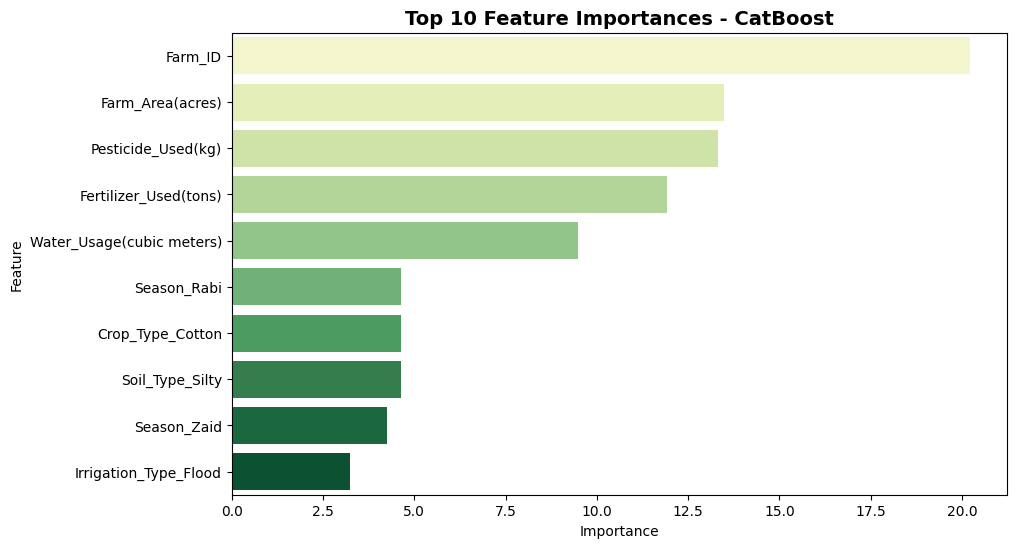

In [20]:
# Ensure X_train is a DataFrame (if it is NumPy array)
if isinstance(X_train, np.ndarray):
    X_train = pd.DataFrame(X_train, columns=df_encoded.drop('Yield(tons)', axis=1).columns)

# Dictionary to store feature importances
feature_importances = {}

# Tree-based models
tree_models = {
    'Random Forest': models['Random Forest'],
    'XGBoost': models['XGBoost'],
    'CatBoost': models['CatBoost']
}

# Store feature importances for tree models
for name, model in tree_models.items():
    feature_importances[name] = pd.Series(model.feature_importances_, index=X_train.columns)

# Linear Regression: absolute value of coefficients
feature_importances['Linear Regression'] = pd.Series(np.abs(models['Linear Regression'].coef_), index=X_train.columns)

# Combine into a single DataFrame
importance_df = pd.DataFrame(feature_importances)

# Top 10 features for CatBoost
cat_features = feature_importances['CatBoost'].sort_values(ascending=False)[:10]

plt.figure(figsize=(10,6))
sns.barplot(x=cat_features.values, y=cat_features.index, palette='YlGn')
plt.title('Top 10 Feature Importances - CatBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:15px; color:yellow; margin:0; font-size:150%; font-family:Pacifico; background-color:#4AB075; overflow:hidden"><b>Conclusion  </b></div>

This analysis provided comprehensive insights into farm-level factors affecting crop yields. Key observations include:  

- Crop yield is influenced by soil type, irrigation methods, and seasonal conditions.  
- High-yielding crops like Tomato and Carrot perform well across multiple seasons and soil types.  
- Efficient water and fertilizer management can optimize productivity while minimizing resource use.  
- Machine learning models, particularly **CatBoost Regressor**, showed the best predictive performance for estimating yields.  

Overall, this notebook demonstrates how exploratory data analysis combined with predictive modeling can guide informed agricultural decisions, improve resource allocation, and enhance crop productivity.


### Instructor  
👩‍🏫 Sir Aammar Tufail

### Author  
✍️ Anila Bukhari

## 📚 Learning Platform
- Website: [https://codanics.com/](https://codanics.com/)  
- YouTube: [https://www.youtube.com/@Codanics](https://www.youtube.com/@Codanics)

## 🔗 Connect with Me
- LinkedIn: [https://www.linkedin.com/in/anila-bukhari-b98a90388/](https://www.linkedin.com/in/anila-bukhari-b98a90388/)  
- GitHub: [https://github.com/anilabukhari02-star](https://github.com/anilabukhari02-star)
